# Optimal control of a single spin by using GOAT over GRAPE

This in an introductory example to compute the gradients in [GOAT](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.120.150401) using the gradients from [GRAPE](10.1016/j.jmr.2004.11.004).
This is performed by using chain rule - 
$$ \frac{\partial J}{\partial p} = \sum_k \frac{\partial J}{\partial c_k} \frac{\partial c_k}{\partial p} $$
where $c_k = c(t_k)$ the 'pixelated' control pulse, $\vec{p}$ are the analytical parameters of the control pulse $c(t) \equiv c(\vec{p}, t) $, and $\frac{\partial J}{\partial c_k}$ are the gradients from GRAPE.

#### 1. Generate a PWC pulse shape

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from cthree.quantity import Quantity

from cthree.signal.pwc_generator import PWCGenerator

Lets define a `FlatTopGaussianEnvelope` with multiple optimisable parameters to check if the optimisation of all the parameters works when we rebuild them with GRAPE propagation. We can rely on Automatic differentiation to obtain the gradient of the pulse wrt its parameters.

In [2]:
from collections.abc import Callable
from functools import partial

from cthree.quantity import Array
import jax.numpy as jnp

from jax import jit
from jax.scipy.special import erf
from cthree.signal.envelopes import Envelope


class FlatTopGaussianEnvelope(Envelope):
    """A flat-top Gaussian envelope."""

    def __init__(
        self,
        amplitude: Quantity | None = None,
        t_up: Quantity | None = None,
        t_down: Quantity | None = None,
        ramp_time: Quantity | None = None,
    ):
        self.__amplitude = amplitude
        self.__t_up = t_up
        self.__t_down = t_down
        self.__ramp_time = ramp_time

        self._gradient_function: Callable | None = None
        self._grad_arg_nums: tuple[int, ...] = ()

    @property
    def amplitude(self) -> Quantity:
        """Get the amplitude of the system."""
        return self.__amplitude

    @amplitude.setter
    def amplitude(self, amplitude: Quantity) -> None:
        self.__amplitude = amplitude

    def get_parameters(self):
        """Get all parameters of the system."""
        return [self.__amplitude, self.__t_up, self.__t_down, self.__ramp_time]

    @partial(jit, static_argnums=(0,))
    def _evaluate(self, amp: Array, t_up: Array, t_down: Array, ramp_time: Array, t: Array):
        rampUp = 1 + erf((t - t_up) / ramp_time)
        rampDown = 1 + erf((-t + t_down) / ramp_time)
        return jnp.squeeze(amp * rampUp * rampDown / 4)

    def compute_output(self, t: Array) -> Array:
        """Compute pulse shape."""
        amp = self.amplitude.get_value()
        t_up = self.__t_up.get_value()
        t_down = self.__t_down.get_value()
        ramp_time = self.__ramp_time.get_value()
        return self._evaluate(amp, t_up, t_down, ramp_time, t)

Define the `Envelope` and the `PWCGenerator`. The `PWCGenerator` is used to produce the pixelated pulse shape for computing the gradients using GRAPE. The optimisation would be performed on the `Envelope` parameters: `amplitude`, `t_up`, `t_down`, `ramp_time`.

In [3]:
t_final = 20e-9
tlist = np.linspace(0, t_final, 26)

tone = FlatTopGaussianEnvelope(
    amplitude=Quantity(np.pi / t_final / 3, -np.pi / t_final, np.pi / t_final, name="Amplitude"),
    t_up=Quantity(1e-9, 0.0, t_final, name="t_up"),
    t_down=Quantity(t_final - 1e-9, 0.0, t_final, name="t_down"),
    ramp_time=Quantity(2e-9, 0.5e-9, t_final, name="ramp_time"),
)

gen = PWCGenerator(envelopes=[tone], tlist=tlist)
gen.multiply_flat_top = True

In [4]:
params = gen.get_parameters()
params[0].set_limits(-200e6, 200e6)
params[1].set_limits(-200e6, 200e6)

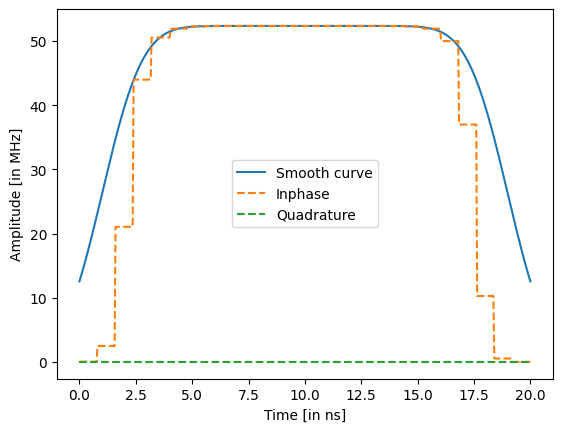

In [5]:
ts = np.linspace(0, t_final, 501)

tone_shape = tone.compute_output(ts)

plt.plot(ts / 1e-9, tone_shape / 1e6, label="Smooth curve")
plt.plot(ts / 1e-9, np.real(gen.generate_signal(ts)) / 1e6, ls="--", label="Inphase")
plt.plot(
    ts / 1e-9,
    np.imag(gen.generate_signal(ts)) / 1e6,
    ls="--",
    label="Quadrature",
)

plt.xlabel("Time [in ns]")
plt.ylabel("Amplitude [in MHz]")
plt.legend()

#### 2. Define Hamiltonian in the rotating frame of drive

As a simple toy model, we use a single spin.

In [6]:
from cthree.model.closed_system import ClosedSystem
from cthree.model.rotating_frame_drive import RotatingFrameDrive
from cthree.model.hamiltonian import Hamiltonian


class SpinRWA(Hamiltonian):
    """A Single Spin."""

    def __init__(self, drives=None):
        super().__init__(drives)
        self.sigma_p = np.array([[0j, 1], [0, 0]])
        self.dim = 2

    def get_matrix_one_time(self, t):
        """Just sigma-X."""
        return self._drives[0].get_matrix_one_time(self.sigma_p, t)

    def gradient(self, t):
        """Gradient is just the drive matrix."""
        return self._drives[0].gradient(self.sigma_p, t)


drive = RotatingFrameDrive(gen)
spin = SpinRWA(drives=[drive])
model = ClosedSystem(spin)

Using GRAPE as the method to propagate and compute the gradients

In [7]:
from cthree.measurement.state_transfer_fidelity import StateTransferFidelityGRAPE
from cthree.propagation.scipy_expm_grape import ScipyExpmGRAPE


prop = ScipyExpmGRAPE(model, res=1e9)

init = np.array([[1.0], [0]])  # |0>
target = np.array([[0.0], [1]])  # |1>

prop.set_initial_state(init)
prop.target_state = target

zeroone = StateTransferFidelityGRAPE(
    propagation=prop,
    initial_state=init,
    target_state=target,
    times=tlist,
)

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

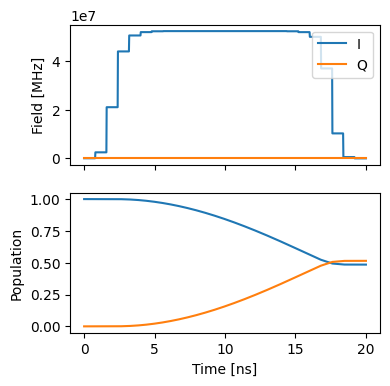

In [8]:
def plotStates():
    """Plot the states."""
    ts = np.linspace(0, t_final, 1001)
    states = prop.propagate(ts)
    sig = gen.generate_signal(ts)

    fig, ax = plt.subplots(2, figsize=(4, 4), sharex=True)
    ax[0].plot(ts / 1e-9, np.real(sig), label="I")
    ax[0].plot(ts / 1e-9, np.imag(sig), label="Q")
    ax[0].legend(loc=1)
    ax[0].set_ylabel("Field [MHz]")
    ax[1].plot(ts / 1e-9, np.abs(states)[:, :, 0] ** 2)
    ax[1].set_ylabel("Population")
    ax[-1].set_xlabel("Time [ns]")
    return fig, ax


plotStates()

Finally, we define the `GOATOverGRAPE` fideltiy that chains together the GRAPE gradients to compute the gradient wrt the tone parameters

In [9]:
from cthree.optimisation_map import OptimisationMap
from cthree.optimisers.scipy_optimiser import ScipyOptimiser
from cthree.optimisers.scipy_optimiser_gradient import ScipyOptimiserGradient
from cthree.measurement.goat_over_grape import GOATOverGRAPE

optmap = OptimisationMap()
optmap.add(tone)
optmap.register_params_with_optimisables()

goat = GOATOverGRAPE(zeroone, gen)

opt = ScipyOptimiser(goat, optimisables=optmap)
optGrad = ScipyOptimiserGradient(goat, optimisables=optmap)

In [10]:
optGrad.optimise()

{'status': 1, 'value': 4.440892098500626e-16, 'iterations': 6, 'message': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL'}

For this simple example, we reach near perfect fidelity within a few iterations.

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

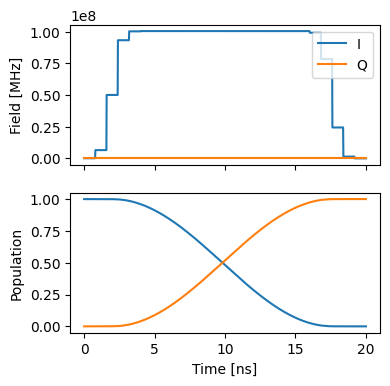

In [11]:
plotStates()

In [12]:
optmap

==== <class '__main__.FlatTopGaussianEnvelope'> ====
[Amplitude: 1.01e+08  , t_up: 5.42e-10  , t_down: 1.94e-08  , ramp_time: 1.31e-09  ]
